In [1]:
from src.data_processor import DataProcessor
from src.model_trainer import ModelTrainer
from src.trajectory_predictor import TrajectoryPredictor

import numpy as np
import os
import random
import tensorflow as tf
import matplotlib.pyplot as plt
from pathlib import Path

BASE_DIR = os.getcwd()

# 시드 값 고정
SEED = 20205136

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

config = {
    'Soccer_looking_left_10m_01.csv': {'skiprows': 500, 'flag': True, 'zone': 52},
    'Soccer_looking_leftright01.csv': {'skiprows': 500, 'flag': True, 'zone': 52},
    'UTAH_looking_01.csv': {'skiprows': 1000, 'flag': True, 'zone': 12},
    'UTAH_looking_02.csv': {'skiprows': 1000, 'flag': True, 'zone': 12},
    'UTAH_looking_03.csv': {'skiprows': 1000, 'flag': True, 'zone': 12},
    'UTAH_looking_04.csv': {'skiprows': 1000, 'flag': True, 'zone': 12},
}

default_config = {'skiprows': 500, 'flag': False, 'zone': 52}



In [2]:
window_size = 200
# ============================================================
# 1. 학습 데이터 로딩 및 전처리
# ============================================================
learn_data_paths = [

os.path.join(BASE_DIR, 'data', 'learn_data', 'Basket_1.csv'),
# os.path.join(BASE_DIR, 'data', 'learn_data', 'Basket_2.csv'),
# #os.path.join(BASE_DIR, 'data', 'learn_data', 'Basket_3.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking1.csv'),
#os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking2.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking3.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking4.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_01.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_02.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking5m_03.csv'),
# os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking_left_10m_01.csv'),
# os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_looking_leftright01.csv'),


os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing1.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing2.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing3.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing4.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_01.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_02.csv'),
os.path.join(BASE_DIR, 'data', 'learn_data', 'Soccer_swing5m_03.csv'),


#--- 유타에서 수집한 데이터 ---#

# os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_Looking_1.csv'),
# os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_test01.csv'),
# os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_01.csv'),
# os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_02.csv'),
# os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_03.csv'),
# os.path.join(BASE_DIR, 'data', 'learn_data', 'UTAH_looking_04.csv'),

]



X_list, Y_list = [], []
df_list = []

for path in learn_data_paths:
    if not os.path.exists(path):
        print(f"학습 파일을 찾을 수 없습니다: {path}")
        continue

    # 파일명으로 옵션 선택
    fname = Path(path).name
    opts = config.get(fname, default_config)

    # 언팩하여 함수 호출
    df_all, x, y = DataProcessor.load_and_preprocess_csv(path, **opts)

    df_list.append(df_all)
    X_list.append(x)
    Y_list.append(y)

# 4) numpy 배열로 변환
X = np.concatenate(X_list, axis=0)  # (batch, 50, feature_dim)
Y = np.concatenate(Y_list, axis=0)  # (batch, 2)

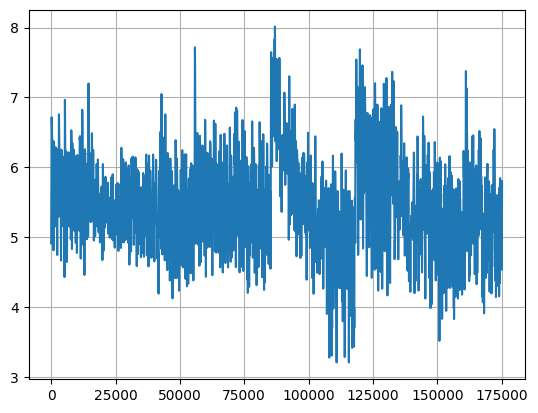

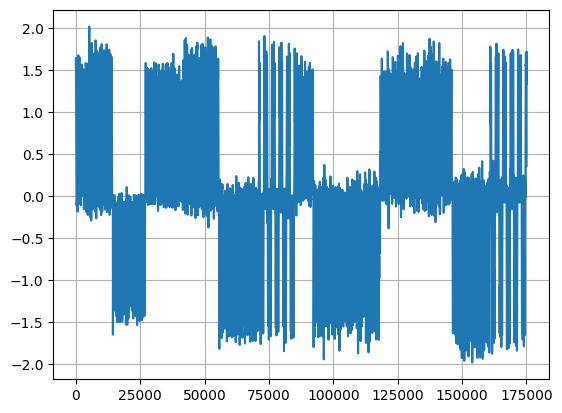

In [3]:
speed = Y[:, 0]
heading_change = Y[:, 1]

plt.plot(speed)
plt.grid()
plt.show()

plt.plot(heading_change)
plt.grid()
plt.show()

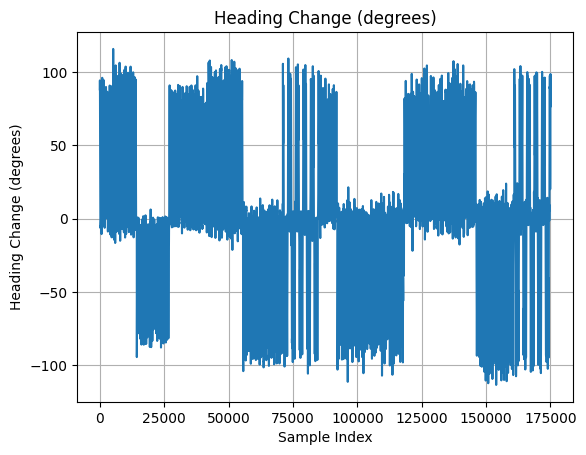

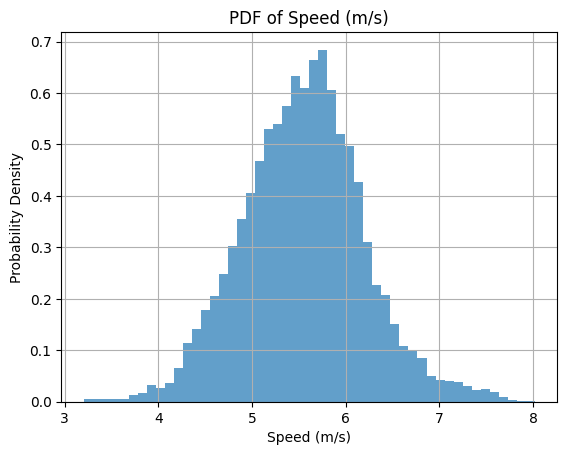

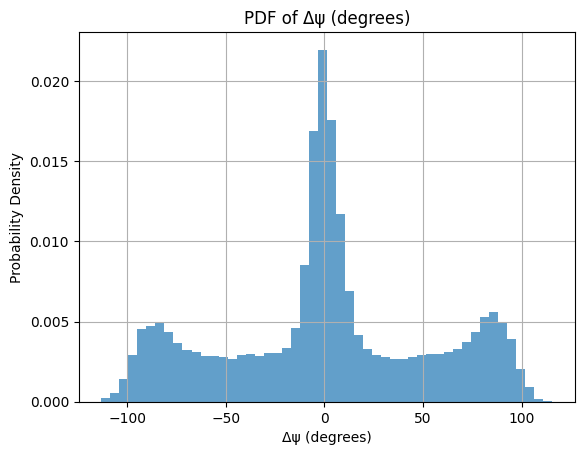

In [4]:
# # ============================================================
# # 이상치 제거: 헤딩 변화량이 100도 초과하는 샘플 제외
# # ============================================================
# degrees_psi = np.degrees(Y[:, 1])
# mask = np.abs(degrees_psi) <= 110
# removed = np.sum(~mask)
# print(f"제거된 샘플 개수: {removed}")

# X = X[mask]
# Y = Y[mask]

# ============================================================
# 5. 데이터 분포 시각화 (optional)
# ============================================================
delta_l = Y[:, 0]     # Distance change
delta_psi = Y[:, 1]   # Heading change

plt.plot(np.degrees(delta_psi))
plt.title('Heading Change (degrees)')
plt.xlabel('Sample Index')
plt.ylabel('Heading Change (degrees)')
plt.grid(True)
plt.show()

def plot_pdf(data, label_name):
    plt.figure()
    plt.hist(data, bins=50, density=True, alpha=0.7)
    plt.xlabel(f'{label_name}')
    plt.ylabel('Probability Density')
    plt.title(f'PDF of {label_name}')
    plt.grid(True)
    plt.show()

plot_pdf(delta_l, 'Speed (m/s)')
plot_pdf(np.degrees(delta_psi), 'Δψ (degrees)')